# ActiTect API Example

## Loading a binary actigraphy file

Use `actitect.api.load(...)` to load any supported binary actigraphy file (Axivity: .cwa, GENEActiv: .bin, ActiGraph: .gt3x and .csv) into memory. This will return a time-indexed pandas.DataFrame object

In [1]:
from pathlib import Path
file = Path.cwd().joinpath('example.cwa')  # choose a filepath, can also be str

from actitect.api import load
raw_df, info = load(file, subject_id='ID-1')
print(raw_df.head(5))

/Users/david/anaconda3/envs/RBDisco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 (16:44:54) - [actitect.actimeter.factory|INFO]: (io: ID-1) detected 'AxivityAx6' device.
 (16:44:54) - [actitect.actimeter.devices.axivity_ax6|INFO]: (io: ID-1) loading from '/Users/david/Desktop/py_projects/aktiRBD_private/actitect/examples/actitect/example.cwa'.
 (16:45:05) - [actitect.utils.data_utils|INFO]: (io: ID-1) found 38 duplicate timestamps.removing ~0.38s of data
 (16:45:06) - [actitect.actimeter.basedevice|INFO]: (io: ID-1) successfully loaded raw data. (12.01s)
                                      x         y         z
time                                                       
2023-10-20 21:00:03.891418368 -0.684082 -0.160645  0.718506
2023-10-20 21:00:03.895416320 -0.689697 -0.163086  0.722900
2023-10-20 21:00:03.899414016 -0.694824 -0.160156  0.727051
2023-10-20 21:00:03.903411968 -0.692139 -0.158936  0.723145
2023-10-20 21:00:03.907409664 -0.685547 -0.161865  0.720947


## Visualizing actigraphy recordings
You can use ActiTect to visualize and inspect the recordings via `actitect.api.plot(...)`. It will draw the tri-axial sensor data, each row corresponding to one day of recording.

/var/folders/yw/nnsjt9xd2895vh6z2h298h100000gn/T/ipykernel_86286/740333084.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


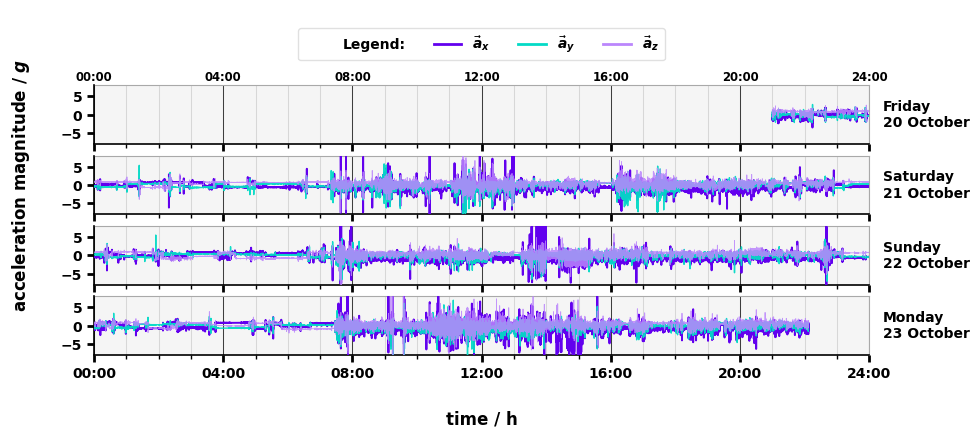

In [2]:
from actitect.api import plot

fig = plot(raw_df) # this will return a matplotlib.figure.Figure object
fig.show()

## Process actigraphy data
To process the actigraphy data use `actitect.api.process(...)`. This will by defualt apply
* **Uniform Resampling** to mitigate sample rate jitter (clock drifts etc)
* **Bandpass Filtering** to filter high and low frequency noise
* **Auto-Calibration** to ensure axes-alignment
* **Non-Wear Detection**
* **Sleep-Window Segmentation**

to the raw actigraphy data to mitigate artifacts and automatically segment non-wear and sleeping periods.

 (16:45:20) - [actitect.actimeter.factory|INFO]: (io: ID-1) detected 'Generic' device (preloaded DataFrame).
 (16:45:22) - [actitect.utils.data_utils|INFO]: (io: ID-1) no duplicate timestamps found.
 (16:45:23) - [actitect.actimeter.basedevice|INFO]: (resampling: ID-1) non-uniform sampling rate in raw data detected: fs = 100.05 ± 24.85 Hz
 (16:46:01) - [actitect.actimeter.basedevice|INFO]: (resampling: ID-1) successful. (37.59s)
 (16:46:05) - [actitect.actimeter.basedevice|INFO]: (filter: ID-1) successful. (3.72s)
 (16:46:11) - [actitect.actimeter.basedevice|INFO]: (calibration: ID-1) calibration error summary: before=18.35mg after=2.71mg.(62 iterations)
 (16:46:11) - [actitect.actimeter.basedevice|INFO]: (calibration: ID-1) successful. (6.01s)
 (16:46:14) - [actitect.actimeter.basedevice|INFO]: (non-wear: ID-1) wear-time-segmentation summary:wear=3.05d, non-wear=0.00d(0 episodes)
 (16:46:14) - [actitect.actimeter.basedevice|INFO]: (non-wear: ID-1) successful. (3.09s)
 (16:46:36) - [ac

/var/folders/yw/nnsjt9xd2895vh6z2h298h100000gn/T/ipykernel_86286/2834898415.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


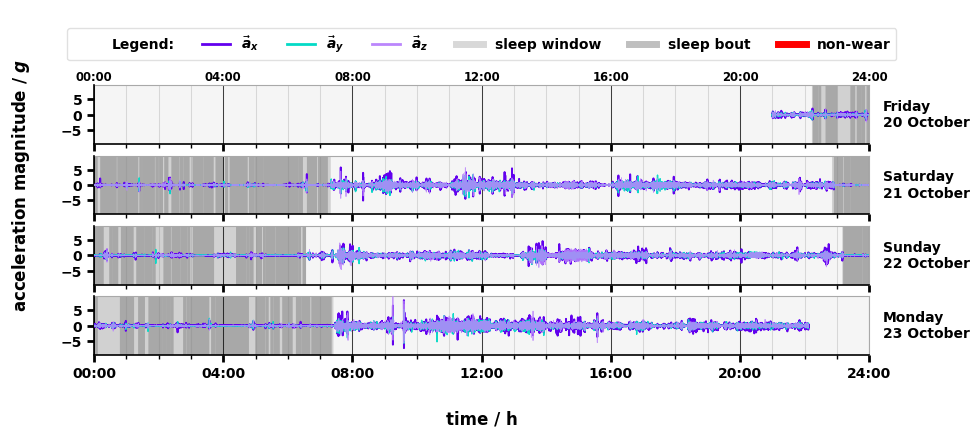

In [3]:
from actitect.api import process, plot

processed_df, info = process(raw_df, subject_id='ID-1') # you can also directly call process(file) one the filepath to load and process the data in one step
# 'info' is a dict that contains information about each processing step.

# plot the processed data
fig = plot(processed_df)
fig.show()

the processed DataFrame will now store the processed data and have additional boolean columns 'wear', 'sptw' and 'sleep_bout' to indicate periods of non-wear (wear==False),  sleep period time windows (sptws==True) and higher-confidence sleep bout periods. If you now call the plotting function, segements will me marked accordingly. If you do not want to use the default settings you can have full control over the processing steps:
```
processed_df = process(
    raw_df,
    resample_rate= 'infer',  # or int to set it directly to nominal sample rate in Hz, pass None to skip uniform resampling.
    highpass_hz= .8,  # or any other float to specify the lower cutoff of the bandpass filter in Hz, set None to skip it.
    lowpass_hz = 20.0, # or any other float to specify the upper cutoff of the bandpass filter in Hz, set None to skip it.
    calibrate=True,  # turn post-hoc auto-calibration on or off.
    detect_nonwear=True, # turn non-wear detection on or off.
    detect_sleep=True # turn sleep segmentation on or off.
)
```

## Feature extraction
Use `actitect.api.compute_sleep_motor_features()` to calculate numerical features from the sleep windows that characterize each nights motor patterns. For more details, refer to the main [README](../../README.md) and our paper.

In [4]:
from actitect.api import compute_sleep_motor_features

features = compute_sleep_motor_features(processed_df)
print(features.head(3))


 (16:47:14) - [actitect.api|INFO]: found 3 full nights of sleep in data.


[PROGRESS]: Computing sleep features: 100%|■■■■■■■■■■| 3/3 [08:39<00:00, 173.16s/it, night=3/3, features=99.8%]                               


 (16:55:58) - [actitect.utils.data_utils|INFO]: found 65688 problematic cells (5e+01% of 92 cols×1571 rows) in 'local_feat_df': NaN: 65688. Using drop=True, replace=None.
 (16:55:59) - [actitect.utils.data_utils|INFO]: local to global aggregation done. (0.15s)
     id record_id  night                    start_time  \
0  none      none      0 2023-10-20 22:13:43.891418368   
1  none      none      1 2023-10-21 22:50:58.891418368   
2  none      none      2 2023-10-22 23:09:58.891418368   

                       end_time  iei_mean_sec  iei_std_sec   iei_var_sec  \
0 2023-10-21 07:19:38.891418368     75.287494   170.233102  28979.308963   
1 2023-10-22 06:33:48.891418368     42.011556   131.412758  17269.312950   
2 2023-10-23 07:24:38.891418368     55.043218   168.491391  28389.348828   

     iei_cv  iei_iqr_sec  ...  sd_ratio_10th_percentile  \
0  2.261107      67.8300  ...                  3.531845   
1  3.128015      28.1325  ...                  3.337278   
2  3.061075      46.5050